# Titanic Dataset: Exploratory Data Analysis (EDA)
## Objective: Understanding Survival Patterns Through Data Cleaning & Visualization

**Project Goal:**
- Clean the raw Titanic dataset
- Perform comprehensive exploratory analysis
- Generate actionable insights through visualizations
- Identify factors influencing passenger survival

## Purpose of This Analysis is to find answers for the given key questions
**Key Questions We will Answer:**
1. What percentage of passengers survived?
2. Which factors most influence survival?
3. Are there gender/class-based survival patterns?
4. What is the fare distribution across classes?
5. Age demographics ke patterns kya hain?


## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

## Data loading

In [2]:
df=pd.read_csv('train.csv')
df
print("Dataset shape:",df.shape)
print("Dataset top 5 rows")
print(df.head())
print("Dataset bottom 5 rows")
print(df.tail())
print("statistics info for columns")
print(df.describe())
print('no of unique entries in each column')
print(df.nunique())
#list of all columns
print(df.columns)

Dataset shape: (891, 12)
Dataset top 5 rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0   

### Handling missing values

In [3]:
df
print("num of missing values", df.isnull().sum())
print(df['Age'].dtype)  # checking datatype
df['Age']=df['Age'].fillna(df['Age'].mean())#handled missing age values 
df.isnull().sum() 

df['Cabin'].dtype #datatype of cabin values
print(df['Cabin'])
df['Cabin']=df['Cabin'].bfill() #handled cabin missing values using backward fillings
df.isnull().sum()
df['Embarked'].dtype
df['Embarked']=df['Embarked'].ffill() #handled embarked missing values using forward fillings

df.isnull().sum()




num of missing values PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
float64
0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: str


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          1
Embarked       0
dtype: int64

### handling duplicatess

In [4]:
df
print(f'Number of duplicated rows:{df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
#no duplicate rows
# df['Cabin'].duplicated()

Number of duplicated rows:0


##

### Feature engineering 

In [5]:
df
# Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 2
#age groups 
df['Agegroup']=pd.cut(df['Age'],bins=[0,11,18,30,70,100],labels=['Child','Teen','Adult','Senior','Elderly'])
df
# Data after Feature engineering 
print(f'\n After feature engineering:')
print(df.head())
print(df.info())


 After feature engineering:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  FamilySize Agegroup  
0      0         A/5 21171   7.2500   C85        S           3    Adult  
1      0          PC 17599  71.2833   C85        C           3   Senior  
2      0  STON/O2. 3101282   7.9250  C123        S           2    Adu

## Data Visualisation

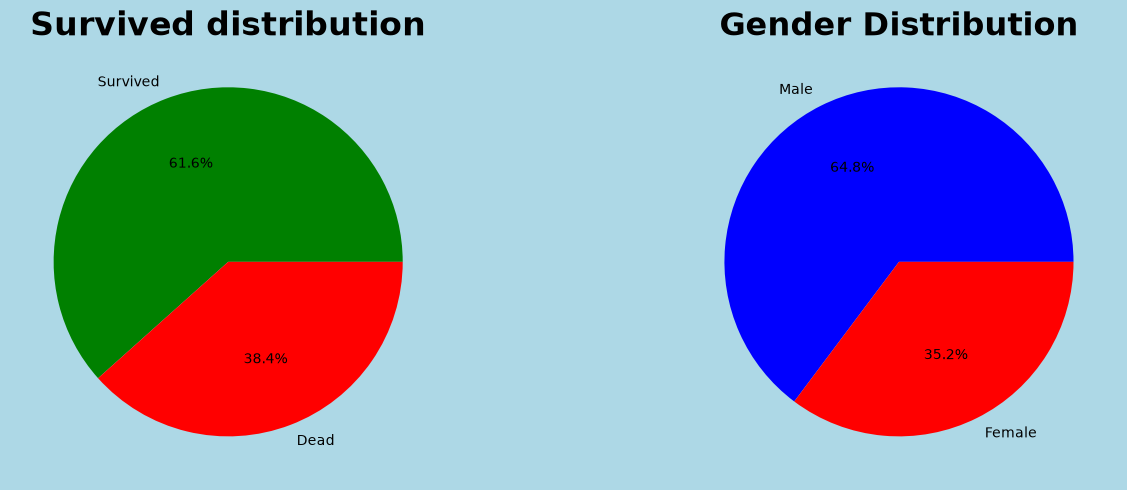

In [6]:
fig,ax=plt.subplots(1,2,figsize=(15,5),facecolor='lightblue')
ax[0].set_facecolor('pink')
ax[1].set_facecolor('pink')

# pie chart 1

survival_counts=df['Survived'].value_counts()
ax[0].pie(survival_counts,labels=['Survived','Dead'],autopct='%1.1f%%',colors=['green','red'])
ax[0].set_title('Survived distribution',fontsize=24,fontweight='bold')

#pie chart 2

gender_counts=df['Sex'].value_counts()
ax[1].pie(gender_counts,labels=['Male','Female'],autopct='%1.1f%%',colors=['Blue','red'])
ax[1].set_title('Gender Distribution',fontsize=23,fontweight='bold')
plt.tight_layout()
plt.show()




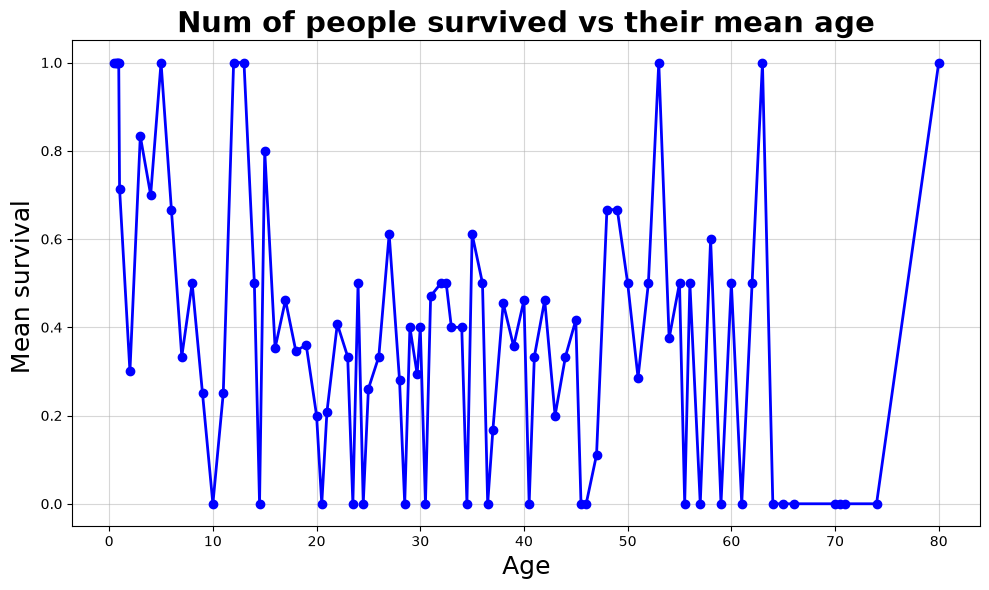

In [16]:
df
survival_by_age=df.groupby('Age')['Survived'].mean()
# print(survival_by_age.values)
plt.figure(figsize=(10,6))
plt.plot(survival_by_age.index,survival_by_age.values,'o-b',linewidth=2)
plt.title('Num of people survived vs their mean age',fontsize=21,fontweight='bold')
plt.xlabel('Age',fontsize=18)
plt.ylabel('Mean survival ',fontsize=18)
plt.tight_layout()
plt.grid(True, alpha=0.5)
plt.show()


In [15]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Agegroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,C85,S,3,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,3,Senior
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,C123,S,2,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,3,Senior
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,E46,S,2,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,B42,S,2,Adult
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,2,Adult
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,C148,S,5,Adult
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,2,Adult


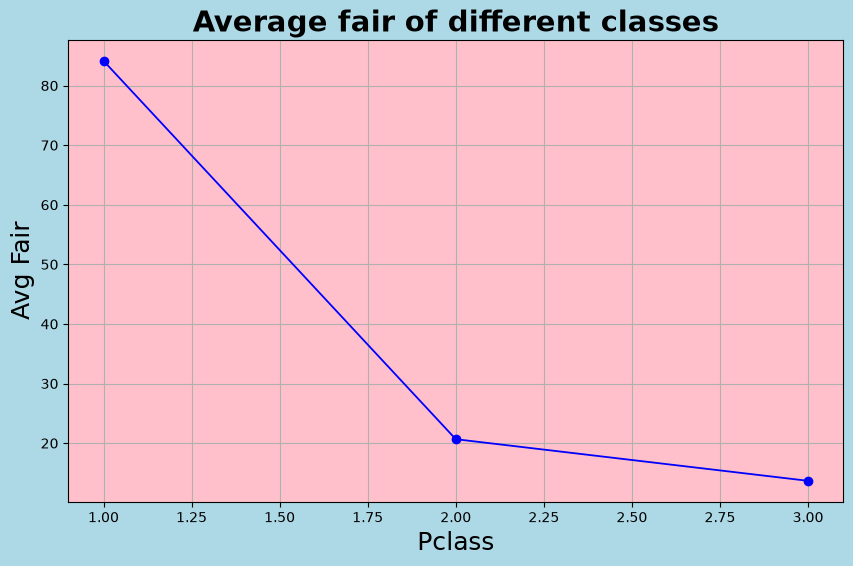

In [29]:
fare_by_class=df.groupby('Pclass')['Fare'].mean()
fig,ax=plt.subplots(figsize=(10,6),facecolor='lightblue')
ax.set_facecolor('pink')
ax.plot(fare_by_class.index,fare_by_class.values,'o-b',linewidth=1.3)
ax.set_title('Average fair of different classes',fontsize=21,fontweight='bold')
ax.set_xlabel('Pclass',fontsize=18)
ax.set_ylabel('Avg Fair',fontsize=18)
ax.grid(True)
plt.show()